C:\Users\ygunj\AppData\Local\Temp\ipykernel_3808\3223959111.py:316: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


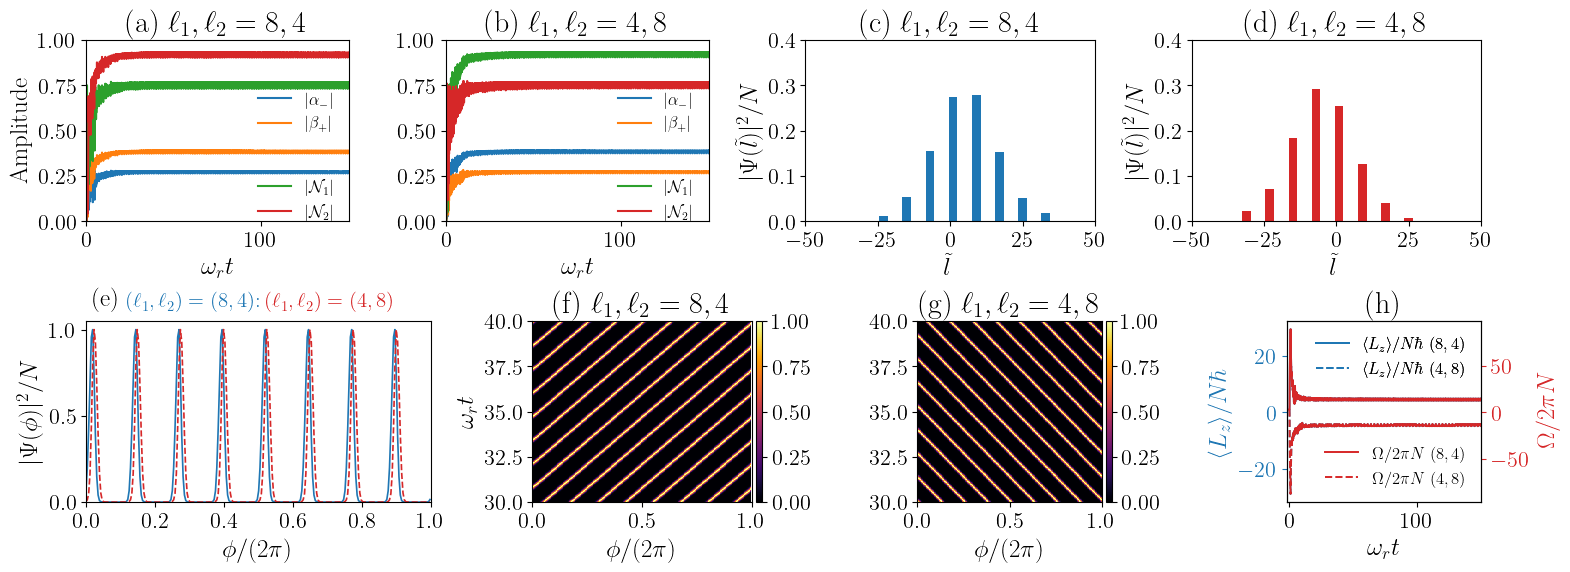

In [14]:
import numpy as np

# ============================================================
# LOAD ROW 1 DATA
# ============================================================
data1 = np.load(r"Figure_16_data_1.npz", allow_pickle=True)

t = data1["t"]
omega_r = data1["omega_r"]

resA = {
    "a_minus": data1["a_minus_A"],
    "b_plus": data1["b_plus_A"],
    "Nop1": data1["Nop1_A"],
    "Nop2": data1["Nop2_A"],
    "l_vals": data1["l_vals_A"],
    "pop_final": data1["pop_final_A"]
}

resB = {
    "a_minus": data1["a_minus_B"],
    "b_plus": data1["b_plus_B"],
    "Nop1": data1["Nop1_B"],
    "Nop2": data1["Nop2_B"],
    "l_vals": data1["l_vals_B"],
    "pop_final": data1["pop_final_B"]
}

# ============================================================
# LOAD DENSITY A (data_2)
# ============================================================
data2 = np.load(r"Figure_16_data_2.npz", allow_pickle=True)

phi = data2["phi"]

resA["density"] = data2["density_A"]

# ============================================================
# LOAD DENSITY B (data_3)
# ============================================================
data3 = np.load(r"Figure_16_data_3.npz", allow_pickle=True)

resB["density"] = data3["density_B"]

# ============================================================
# LOAD OBSERVABLES (data_4)
# ============================================================
data4 = np.load(r"Figure_16_data_4.npz", allow_pickle=True)

hbar = data4["hbar"]

resA["Lz"] = data4["Lz_A"]
resB["Lz"] = data4["Lz_B"]

resA["Omega"] = data4["Omega_A"]
resB["Omega"] = data4["Omega_B"]

# ============================================================
# FINAL GRID
# ============================================================
phi_grid = phi

# ============================================================
# COMPLETE LaTeX-STYLE PLOTTING CODE (2 x 4 PANELS) — CLEANED
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec

# ---------------- LaTeX / journal style ----------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 18,
    "axes.linewidth": 0.8,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
    "figure.facecolor": "white"
})


fig = plt.figure(figsize=(18, 6))

# ================= MASTER GRID =================
gs_master = gridspec.GridSpec(
    2, 1,
    height_ratios=[0.85, 0.85],
    hspace=0.55
)

# ================= FIRST ROW =================
gs_top = gridspec.GridSpecFromSubplotSpec(
    1, 4,
    subplot_spec=gs_master[0],
    width_ratios=[1, 1, 1.1, 1.1],
    wspace=0.35
)

# ================= SECOND ROW =================
gs_bottom_master = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=gs_master[1],
    width_ratios=[1.2, 1.0],
    wspace=0.25
)

gs_bottom_left = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=gs_bottom_master[0],
    width_ratios=[0.9, 0.6],
    wspace=0.35
)

gs_bottom_right = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=gs_bottom_master[1],
    width_ratios=[0.6, 0.6],
    wspace=0.9
)

# ================= AXES =================
axes = np.empty((2, 4), dtype=object)

for j in range(4):
    axes[0, j] = fig.add_subplot(gs_top[0, j])

axes[1, 0] = fig.add_subplot(gs_bottom_left[0, 0])
axes[1, 1] = fig.add_subplot(gs_bottom_left[0, 1])
axes[1, 2] = fig.add_subplot(gs_bottom_right[0, 0])
axes[1, 3] = fig.add_subplot(gs_bottom_right[0, 1])

# ============================================================
# FIRST ROW
# ============================================================

# (a)
ax = axes[0, 0]
l1, = ax.plot(omega_r*t, np.abs(resA["a_minus"]), label=r"$|\alpha_-|$")
l2, = ax.plot(omega_r*t, np.abs(resA["b_plus"]), label=r"$|\beta_+|$")
l3, = ax.plot(omega_r*t, np.abs(resA["Nop1"]), label=r"$|\mathcal{N}_1|$")
l4, = ax.plot(omega_r*t, np.abs(resA["Nop2"]), label=r"$|\mathcal{N}_2|$")

ax.set_title(r"(a) $\ell_1,\ell_2=8,4$")
ax.set_xlabel(r"$\omega_r t$")
ax.set_ylabel("Amplitude")
ax.set_xlim([-0.2, 150])
ax.set_ylim([0, 1])

# Create first legend with first two lines (upper right)
legend1 = ax.legend(handles=[l1, l2], loc='upper right', bbox_to_anchor=(1, 0.8), fontsize=12)

# Add first legend as an artist so it persists
ax.add_artist(legend1)

# Create second legend with last two lines (lower right)
ax.legend(handles=[l3, l4], loc='lower right',bbox_to_anchor=(1, -0.08),  fontsize=12)


# (b)
ax = axes[0, 1]
l1, = ax.plot(omega_r*t, np.abs(resB["a_minus"]), label=r"$|\alpha_-|$")
l2, = ax.plot(omega_r*t, np.abs(resB["b_plus"]), label=r"$|\beta_+|$")
l3, = ax.plot(omega_r*t, np.abs(resB["Nop1"]), label=r"$|\mathcal{N}_1|$")
l4, = ax.plot(omega_r*t, np.abs(resB["Nop2"]), label=r"$|\mathcal{N}_2|$")

ax.set_title(r"(b) $\ell_1,\ell_2=4,8$")
ax.set_xlabel(r"$\omega_r t$")
ax.set_xlim([-0.2, 150])
ax.set_ylim([0, 1])

# Create first legend with first two lines (upper right)
legend1 = ax.legend(handles=[l1, l2], loc='upper right', bbox_to_anchor=(1, 0.8), fontsize=12)

# Add first legend as an artist so it persists
ax.add_artist(legend1)

# Create second legend with last two lines (lower right)
ax.legend(handles=[l3, l4], loc='lower right',bbox_to_anchor=(1, -0.08),  fontsize=12)

# (c)
ax = axes[0, 2]
ax.bar(resA["l_vals"], resA["pop_final"], width=3, color="C0")
ax.set_title(r"(c) $\ell_1,\ell_2=8,4$")
ax.set_xlabel(r"$\tilde{l}$")
ax.set_ylabel(r"$|\Psi(\tilde{l})|^2/N$")
ax.set_xlim([-50, 50])
ax.set_ylim([0, 0.4])

# (d)
ax = axes[0, 3]
ax.bar(resB["l_vals"], resB["pop_final"], width=3, color="C3")
ax.set_title(r"(d) $\ell_1,\ell_2=4,8$")
ax.set_xlabel(r"$\tilde{l}$")
ax.set_ylabel(r"$|\Psi(\tilde{l})|^2/N$")
ax.set_xlim([-50, 50])
ax.set_ylim([0, 0.4])

# ============================================================
# SECOND ROW (CLEAN APS STYLE)
# ============================================================

# (e)
ax = axes[1, 0]
ax.plot(phi_grid/(2*np.pi), resA["density"][-1], color="C0", lw=1.2)
ax.plot(phi_grid/(2*np.pi), resB["density"][-1], color="C3", lw=1.2, ls="--")

# ax.set_title(r"(e)")
ax.set_xlabel(r"$\phi/(2\pi)$")
ax.set_ylabel(r"$|\Psi(\phi)|^2/N$")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

# ---- colored title (centered, LaTeX-safe) ----
ax.text(
    0.1, 1.05, r"(e)",
    transform=ax.transAxes,
    color="black", fontsize=18,
    ha="right", va="bottom"
)
ax.text(
    0.12, 1.05, r" $(\ell_1,\ell_2)=(8,4)$:",
    transform=ax.transAxes,
    color="C0", fontsize=15,
    ha="left", va="bottom"
)



ax.text(
    0.52, 1.05, r"$(\ell_1,\ell_2)=(4,8)$",
    transform=ax.transAxes,
    color="C3", fontsize=15,
    ha="left", va="bottom"
)

# (f)
ax = axes[1, 1]
im1 = ax.pcolormesh(
    phi_grid/(2*np.pi), t*omega_r, resA["density"],
    shading="auto", cmap="inferno", vmin=0, vmax=1
)
ax.set_title(r"(f) $\ell_1,\ell_2=8,4$")
ax.set_xlabel(r"$\phi/(2\pi)$")
ax.set_ylabel(r"$\omega_r t$")
ax.set_ylim([30, 40])
ax.set_xlim([0, 1])

# (g)
ax = axes[1, 2]
im2 = ax.pcolormesh(
    phi_grid/(2*np.pi), t*omega_r, resB["density"],
    shading="auto", cmap="inferno", vmin=0, vmax=1
)
ax.set_title(r"(g) $\ell_1,\ell_2=4,8$")
ax.set_xlabel(r"$\phi/(2\pi)$")
ax.set_ylim([30, 40])
ax.set_xlim([0, 1])

# (h)
ax = axes[1, 3]

l1, = ax.plot(
    omega_r*t, resA["Lz"]/hbar,
    color="C0", lw=1.4,
    label=r"$\langle L_z\rangle/N\hbar\ (8,4)$"
)

l2, = ax.plot(
    omega_r*t, resB["Lz"]/hbar,
    color="C0", lw=1.4, ls="--",
    label=r"$\langle L_z\rangle/N\hbar\ (4,8)$"
)

ax.set_title(r"(h)")
ax.set_xlabel(r"$\omega_r t$")
ax.set_ylabel(r"$\langle L_z\rangle/N\hbar$", color="C0")
ax.tick_params(axis="y", colors="C0")
ax.set_xlim([-2, 150])

ax2 = ax.twinx()

l3, = ax2.plot(
    omega_r*t, resA["Omega"]/(2*np.pi),
    color="C3", lw=1.4,
    label=r"$\Omega/2\pi N\ (8,4)$"
)

l4, = ax2.plot(
    omega_r*t, resB["Omega"]/(2*np.pi),
    color="C3", lw=1.4, ls="--",
    label=r"$\Omega/2\pi N\ (4,8)$"
)

ax2.set_ylabel(r"$\Omega/2\pi N$", color="C3")
ax2.tick_params(axis="y", colors="C3")

leg1 = ax.legend(handles=[l1, l2], loc="upper right", fontsize=12)
leg2 = ax2.legend(handles=[l3, l4], loc="lower right", fontsize=12)
ax.add_artist(leg1)

# ================= COLORBARS =================
divider1 = make_axes_locatable(axes[1, 1])
cax1 = divider1.append_axes("right", size="3%", pad=0.04)
fig.colorbar(im1, cax=cax1)

divider2 = make_axes_locatable(axes[1, 2])
cax2 = divider2.append_axes("right", size="3%", pad=0.04)
fig.colorbar(im2, cax=cax2)

plt.tight_layout()
plt.show()